In [130]:
import pandas as pd 
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

orders = pd.read_csv('olist_orders_dataset.csv')
orders_item = pd.read_csv('olist_order_items_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
sellers = pd.read_csv('olist_sellers_dataset.csv')
payment = pd.read_csv('olist_order_payments_dataset.csv')
category_name = pd.read_csv('product_category_name_translation.csv')
location= pd.read_csv('olist_geolocation_dataset.csv')

In [131]:
payment.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


# orders

In [132]:
orders.shape

(99441, 8)

In [133]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [134]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [135]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [136]:
(orders.isnull().mean())*100

order_id                         0.000000
customer_id                      0.000000
order_status                     0.000000
order_purchase_timestamp         0.000000
order_approved_at                0.160899
order_delivered_carrier_date     1.793023
order_delivered_customer_date    2.981668
order_estimated_delivery_date    0.000000
dtype: float64

In [137]:
orders.loc[orders["order_delivered_customer_date"].isna(),["order_status","order_delivered_customer_date"]]

,order_status,order_delivered_customer_date
6,invoiced,NaN
44,shipped,NaN
103,invoiced,NaN
128,processing,NaN
154,shipped,NaN
...,...,...
99283,canceled,NaN
99313,processing,NaN
99347,canceled,NaN
99348,unavailable,NaN


In [138]:
orders["order_status"].unique()

array(['delivered', 'invoiced', 'shipped', 'processing', 'unavailable',
       'canceled', 'created', 'approved'], dtype=object)

In [139]:
orders[orders['order_delivered_customer_date'].isna()]['order_status'].value_counts()

order_status
shipped        1107
canceled        619
unavailable     609
invoiced        314
processing      301
delivered         8
created           5
approved          2
Name: count, dtype: int64

In [140]:
orders[(orders['order_delivered_customer_date'].isna()) &(orders['order_status'] == 'delivered')].head(8)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
3002,2d1e2d5bf4dc7227b3bfebb81328c15f,ec05a6d8558c6455f0cbbd8a420ad34f,delivered,2017-11-28 17:44:07,2017-11-28 17:56:40,2017-11-30 18:12:23,NaN,2017-12-18 00:00:00
20618,f5dd62b788049ad9fc0526e3ad11a097,5e89028e024b381dc84a13a3570decb4,delivered,2018-06-20 06:58:43,2018-06-20 07:19:05,2018-06-25 08:05:00,NaN,2018-07-16 00:00:00
43834,2ebdfc4f15f23b91474edf87475f108e,29f0540231702fda0cfdee0a310f11aa,delivered,2018-07-01 17:05:11,2018-07-01 17:15:12,2018-07-03 13:57:00,NaN,2018-07-30 00:00:00
79263,e69f75a717d64fc5ecdfae42b2e8e086,cfda40ca8dd0a5d486a9635b611b398a,delivered,2018-07-01 22:05:55,2018-07-01 22:15:14,2018-07-03 13:57:00,NaN,2018-07-30 00:00:00
82868,0d3268bad9b086af767785e3f0fc0133,4f1d63d35fb7c8999853b2699f5c7649,delivered,2018-07-01 21:14:02,2018-07-01 21:29:54,2018-07-03 09:28:00,NaN,2018-07-24 00:00:00
92643,2d858f451373b04fb5c984a1cc2defaf,e08caf668d499a6d643dafd7c5cc498a,delivered,2017-05-25 23:22:43,2017-05-25 23:30:16,NaN,NaN,2017-06-23 00:00:00
97647,ab7c89dc1bf4a1ead9d6ec1ec8968a84,dd1b84a7286eb4524d52af4256c0ba24,delivered,2018-06-08 12:09:39,2018-06-08 12:36:39,2018-06-12 14:10:00,NaN,2018-06-26 00:00:00
98038,20edc82cf5400ce95e1afacc25798b31,28c37425f1127d887d7337f284080a0f,delivered,2018-06-27 16:09:12,2018-06-27 16:29:30,2018-07-03 19:26:00,NaN,2018-07-19 00:00:00


In [141]:
orders.duplicated().sum()

0

In [142]:
orders.nunique()

order_id                         99441
customer_id                      99441
order_status                         8
order_purchase_timestamp         98875
order_approved_at                90733
order_delivered_carrier_date     81018
order_delivered_customer_date    95664
order_estimated_delivery_date      459
dtype: int64

In [143]:
orders['order_status'].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [144]:
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_carrier_date'] = pd.to_datetime(orders['order_delivered_carrier_date'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

In [145]:
orders['year'] = orders['order_purchase_timestamp'].dt.year
orders['month'] = orders['order_purchase_timestamp'].dt.month
orders['quarter'] = orders['order_purchase_timestamp'].dt.quarter
orders['weekday'] = orders['order_purchase_timestamp'].dt.day_name()
orders['hour'] = orders['order_purchase_timestamp'].dt.hour

In [146]:
clean_orders = orders[(orders["year"] == 2017) |((orders["year"] == 2018) & (orders["month"] <= 8))]

In [147]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,year,month,quarter,weekday,hour
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,10,4,Monday,10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018,7,3,Tuesday,20
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018,8,3,Wednesday,8
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017,11,4,Saturday,19
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018,2,1,Tuesday,21


## orders_item 

In [148]:
orders_item.shape

(112650, 7)

In [149]:
orders_item.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [150]:
orders_item.isnull().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [151]:
orders_item.duplicated().sum()

0

In [152]:
orders_item.describe()

,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


## customers

In [153]:
customers.shape

(99441, 5)

In [154]:
customers.isnull().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [155]:
customers.duplicated().sum()

0

In [156]:
customers['customer_unique_id'].nunique()

96096

In [157]:
# العميل المميز جم مره طلب 
customers['customer_unique_id'].value_counts()

customer_unique_id
8d50f5eadf50201ccdcedfb9e2ac8455    17
3e43e6105506432c953e165fb2acf44c     9
1b6c7548a2a1f9037c1fd3ddfed95f33     7
ca77025e7201e3b30c44b472ff346268     7
6469f99c1f9dfae7733b25662e7f1782     7
                                    ..
081f07439678af2da7755a0aa572154d     1
9c57789a6a587f4efcfb01e36c106014     1
9e4c21635f640562de1a6976374fba03     1
06c0ea6ee892364d1608ee47aa9f56a0     1
84732c5050c01db9b23e19ba39899398     1
Name: count, Length: 96096, dtype: int64

In [158]:
customers['customer_state'] = customers['customer_state'].str.upper().str.strip()

In [30]:
customers['customer_state'].value_counts()

customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
PE     1652
CE     1336
PA      975
MT      907
MA      747
MS      715
PB      536
PI      495
RN      485
AL      413
SE      350
TO      280
RO      253
AM      148
AC       81
AP       68
RR       46
Name: count, dtype: int64

## products 

In [159]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [160]:
products[products["product_category_name"].isna()]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
105,a41e356c76fab66334f36de622ecbd3a,NaN,NaN,NaN,NaN,650.0,17.0,14.0,12.0
128,d8dee61c2034d6d075997acef1870e9b,NaN,NaN,NaN,NaN,300.0,16.0,7.0,20.0
145,56139431d72cd51f19eb9f7dae4d1617,NaN,NaN,NaN,NaN,200.0,20.0,20.0,20.0
154,46b48281eb6d663ced748f324108c733,NaN,NaN,NaN,NaN,18500.0,41.0,30.0,41.0
197,5fb61f482620cb672f5e586bb132eae9,NaN,NaN,NaN,NaN,300.0,35.0,7.0,12.0
...,...,...,...,...,...,...,...,...,...
32515,b0a0c5dd78e644373b199380612c350a,NaN,NaN,NaN,NaN,1800.0,30.0,20.0,70.0
32589,10dbe0fbaa2c505123c17fdc34a63c56,NaN,NaN,NaN,NaN,800.0,30.0,10.0,23.0
32616,bd2ada37b58ae94cc838b9c0569fecd8,NaN,NaN,NaN,NaN,200.0,21.0,8.0,16.0
32772,fa51e914046aab32764c41356b9d4ea4,NaN,NaN,NaN,NaN,1300.0,45.0,16.0,45.0


In [161]:
(products.isnull().mean()) *100

product_id                    0.000000
product_category_name         1.851234
product_name_lenght           1.851234
product_description_lenght    1.851234
product_photos_qty            1.851234
product_weight_g              0.006070
product_length_cm             0.006070
product_height_cm             0.006070
product_width_cm              0.006070
dtype: float64

In [162]:
products.duplicated().sum()

0

In [163]:
products.nunique()

product_id                    32951
product_category_name            73
product_name_lenght              66
product_description_lenght     2960
product_photos_qty               19
product_weight_g               2204
product_length_cm                99
product_height_cm               102
product_width_cm                 95
dtype: int64

In [164]:
products = products.merge(category_name,on='product_category_name',how='left')
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0,housewares


In [165]:
missing = products[~products['product_category_name'].isin(category_name['product_category_name'])]
missing['product_category_name'].unique()

array([nan, 'pc_gamer', 'portateis_cozinha_e_preparadores_de_alimentos'],
      dtype=object)

In [166]:
products.loc[products['product_category_name'] == 'pc_gamer','product_category_name_english'] = 'gaming PC'

products.loc[products['product_category_name'] == 'portateis_cozinha_e_preparadores_de_alimentos', 'product_category_name_english'] = 'portable kitchen food processors'

## sellers

In [167]:
sellers.isnull().sum()

seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

In [168]:
sellers['seller_id'].duplicated().sum()

0

In [169]:
sellers['seller_state'] = sellers['seller_state'].str.upper().str.strip()

In [170]:
# عشان نربط المناطق اللي فيها بائعين بس مافيها مشترين او العكس 
sellers['seller_state'].value_counts()

seller_state
SP    1849
PR     349
MG     244
SC     190
RJ     171
RS     129
GO      40
DF      30
ES      23
BA      19
CE      13
PE       9
PB       6
RN       5
MS       5
MT       4
RO       2
SE       2
PI       1
AC       1
MA       1
AM       1
PA       1
Name: count, dtype: int64

## payment

In [171]:
payment.isnull().sum()

order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

In [172]:
payment.duplicated().sum()

0

In [173]:
payment['payment_type'].value_counts()

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

In [174]:
# حق عدد الاقساط 
payment['payment_installments'].describe()

count    103886.000000
mean          2.853349
std           2.687051
min           0.000000
25%           1.000000
50%           1.000000
75%           4.000000
max          24.000000
Name: payment_installments, dtype: float64

In [175]:
payment[payment['payment_type'] == 'not_defined']

,order_id,payment_sequential,payment_type,payment_installments,payment_value
51280,4637ca194b6387e2d538dc89b124b0ee,1,not_defined,1,0.0
57411,00b1cb0320190ca0daa2c88b35206009,1,not_defined,1,0.0
94427,c8c528189310eaa44a745b8d9d26908b,1,not_defined,1,0.0


In [176]:
(payment['payment_value'] == 0).sum()

9

In [177]:
payment[payment['payment_value'] == 0]

,order_id,payment_sequential,payment_type,payment_installments,payment_value
19922,8bcbe01d44d147f901cd3192671144db,4,voucher,1,0.0
36822,fa65dad1b0e818e3ccc5cb0e39231352,14,voucher,1,0.0
43744,6ccb433e00daae1283ccc956189c82ae,4,voucher,1,0.0
51280,4637ca194b6387e2d538dc89b124b0ee,1,not_defined,1,0.0
57411,00b1cb0320190ca0daa2c88b35206009,1,not_defined,1,0.0
62674,45ed6e85398a87c253db47c2d9f48216,3,voucher,1,0.0
77885,fa65dad1b0e818e3ccc5cb0e39231352,13,voucher,1,0.0
94427,c8c528189310eaa44a745b8d9d26908b,1,not_defined,1,0.0
100766,b23878b3e8eb4d25a158f57d96331b18,4,voucher,1,0.0


In [178]:
payment['payment_value'].describe()

count    103886.000000
mean        154.100380
std         217.494064
min           0.000000
25%          56.790000
50%         100.000000
75%         171.837500
max       13664.080000
Name: payment_value, dtype: float64

# Sara's analysis

# Data completeness

In [1]:
orders["order_purchase_timestamp"].min()

NameError: name 'orders' is not defined

In [ ]:
orders["order_purchase_timestamp"].max()

In [ ]:
orders.groupby("year")["month"].unique()# to look at the available months in each year

In [ ]:
# the only complete year we have is 2017

In [ ]:
orders.groupby(["year","month"])["order_id"].nunique() #look at the number of orders in each

In [ ]:
monthly = orders.groupby(["year","month"])["order_id"].count()
monthly.loc[(2016, 11)] = 0
monthly = monthly.sort_index()
figsize=(15,5)
monthly.plot(kind="bar")

In [ ]:
# We will be using this period, starting from jan 2017 - Aug 2028

In [ ]:
clean_orders = orders[(orders["year"] == 2017) |((orders["year"] == 2018) & (orders["month"] <= 8))]

# Sales

In [ ]:
# Sales, what the compnay sold (sum the price of each order)

In [ ]:
sales = orders_item.groupby("order_id").agg(sales=("price", "sum")).reset_index()

In [ ]:
sales["sales"].sum()

In [ ]:
# merge sales with orders
clean_orders = clean_orders.merge(sales, on="order_id", how="left")

# KPI's

In [ ]:
total_sales = clean_orders["sales"].sum()

print(total_sales)

In [ ]:
AOV = total_sales / clean_orders["order_id"].nunique()

print(AOV)

In [ ]:
# Revenue
payment["payment_value"].sum()

In [ ]:
# total orders
clean_orders["order_id"].sum()

In [ ]:
orders = clean_orders[~clean_orders["order_status"].isin(["canceled", "unavailable"])]
df = clean_orders.merge(customers[["customer_id", "customer_unique_id"]], on="customer_id")

total_orders = df["order_id"].nunique()
total_customers = df["customer_unique_id"].nunique()

In [ ]:
total_customers

In [ ]:
total_orders

In [ ]:
# Sales growth

In [ ]:
monthly_sales = clean_orders.groupby(["year", "month"])["sales"].sum()

In [ ]:
print(monthly_sales)

In [ ]:
first = monthly_sales.iloc[0]
last = monthly_sales.iloc[-1]

growth = (last - first) / first * 100

growth

# Sales performance

In [ ]:
quarterly_sales = clean_orders.groupby(["year", "quarter"])["sales"].sum().plot(kind="line")

In [ ]:
monthly_sales = clean_orders.groupby(["year", "month"])["sales"].sum()

sales_2017 = monthly_sales.loc[2017] / 1000000
sales_2018 = monthly_sales.loc[2018] / 1000000

plt.figure(figsize=(10,5))

plt.plot(sales_2017.index, sales_2017.values, marker="o", label="2017")
plt.plot(sales_2018.index, sales_2018.values, marker="o", label="2018")

plt.title("Monthly Sales: 2017 vs 2018")
plt.xlabel("Month")
plt.ylabel("Sales (Million R$)")
plt.xticks(range(1, 12))
plt.legend()
plt.show()

# AOV VS Total Orders

In [ ]:
# Total orders

In [ ]:
clean_orders["order_id"].count()

In [ ]:
# total orders over time/ AOV

In [ ]:
quarterly = clean_orders.groupby(["year", "quarter"]).agg(sales=("sales", "sum"),orders=("order_id", "nunique"))

quarterly["AOV"] = quarterly["sales"] / quarterly["orders"]

In [ ]:
quarterly

In [ ]:
quarterly["orders"].plot(kind="bar")

In [ ]:
quarterly["AOV"].plot(kind="line")

In [ ]:
AOV = clean_orders["sales"].sum()/clean_orders["order_id"].count()

In [ ]:
AOV

In [ ]:
monthly = clean_orders.groupby(["year", "month"]).agg(sales=("sales", "sum"),orders=("order_id", "nunique"))

monthly["AOV"] = monthly["sales"] / monthly["orders"]

In [ ]:
monthly["AOV"].plot(kind="line")

In [ ]:
monthly = clean_orders.groupby(["year", "month"]).agg(sales=("sales", "sum"),orders=("order_id", "nunique"))

monthly["AOV"] = monthly["sales"] / monthly["orders"]
monthly["AOV_mean"] = monthly["AOV"].mean()

In [ ]:
monthly["orders_index"] = monthly["orders"] / monthly["orders"].iloc[0] * 100
monthly["AOV_index"] = monthly["AOV"] / monthly["AOV"].iloc[0] * 100

In [ ]:
quarterly["orders"].plot(kind="line", marker="o")

plt.title("Orders Over Time")
plt.xlabel("Quarter")
plt.ylabel("Number of Orders")
plt.show()

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(quarterly.index.astype(str), quarterly["AOV"], marker="o")

plt.title("AOV Over Time")
plt.xlabel("Quarter")
plt.ylabel("AOV")
plt.ylim(0, 200)

plt.show()

In [ ]:
monthly["orders_index"] = monthly["orders"] / monthly["orders"].iloc[0] * 100
monthly["AOV_index"] = monthly["AOV"] / monthly["AOV"].iloc[0] * 100

In [ ]:
plt.plot(monthly.index, monthly["orders_index"], label="Orders")
plt.plot(monthly.index, monthly["AOV_index"], label="AOV")

plt.title("Orders vs AOV")
plt.ylabel("Index (Jan 2017 = 100)")
plt.legend()
plt.show()

# When do customers buy?

In [ ]:
monthly_orders = clean_orders.groupby(["year", "month"])["sales"].mean()

In [ ]:
weekday_orders.plot(kind="bar")
plt.title("Orders by Day of Week")
plt.xlabel("Day")
plt.ylabel("Sales")
plt.show()

In [ ]:
clean_orders.groupby("hour")["sales"].mean().plot(kind="line")

In [ ]:
monthly_sales = clean_orders.groupby(["year", "month"])["sales"].sum()

average_monthly_sales = monthly_sales.groupby("month").mean()

In [ ]:
average_monthly_sales = average_monthly_sales / 1000000

average_monthly_sales.plot(kind="bar")

plt.title("Average Sales by Month")
plt.xlabel("Month")
plt.ylabel("Sales in (Millions)")
plt.show()

# Seasonality: festivals, holidays, summer

In [ ]:
monthly_sales = clean_orders.groupby(["year", "month"])["sales"].mean()

In [ ]:
monthly_sales.plot(kind="bar", figsize=(12,5))

plt.title("Monthly Sales")
plt.xlabel("Year and Month")
plt.ylabel("Sales")
plt.show()

# summer vs other months sales

In [ ]:
summer = clean_orders[(clean_orders["year"] == 2017) &(clean_orders["month"].isin([1, 2, 12]))]
other_months = clean_orders[(clean_orders["year"] == 2017) &(~clean_orders["month"].isin([1, 2, 12]))]

In [ ]:
summer_sales = summer.groupby("month")["sales"].sum().mean()
other_sales = other_months.groupby("month")["sales"].sum().mean()

print("Average summer sales:", summer_sales)
print("Average other monthly sales:", other_sales)

In [ ]:
difference = (560475.2133333334 - 370510.02) / 560475.2133333334 * 100
print(difference)

# GeoLocation

In [179]:
location = pd.read_csv("olist_geolocation_dataset.csv")

In [180]:
location.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [181]:
location.duplicated().sum()

261831

In [182]:
location.isnull().sum()

geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64

# noor analysis

## Geographic 

In [183]:
import matplotlib.pyplot as plt 

In [184]:
#I excluded them because we are focusing solely on sales
Exclude = ['canceled', 'unavailable']
orders = clean_orders[['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp']]

In [185]:
# merge orders with item 
items = orders_item.merge(orders,on='order_id',how='left')
items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51


In [186]:
items[['customer_id', 'order_status', 'order_purchase_timestamp']].isna().sum()

customer_id                 371
order_status                371
order_purchase_timestamp    371
dtype: int64

In [187]:
# merge item with customers
customers = customers[['customer_id', 'customer_unique_id', 'customer_state']]
items = items.merge(customers,on='customer_id',how='left')

In [188]:
items[['customer_unique_id', 'customer_state']].isna().sum()

customer_unique_id    371
customer_state        371
dtype: int64

In [189]:
# merge item with sellers
seller = sellers[['seller_id', 'seller_state']]
items = items.merge(seller, on='seller_id', how='left')
items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,customer_unique_id,customer_state,seller_state
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,871766c5855e863f6eccc05f988b23cb,RJ,SP
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,eb28e67c4c0b83846050ddfb8a35d051,SP,SP
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,3818d81c6709e39d06b2738a8d3a2474,MG,MG
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,af861d436cfc08b2c2ddefd0ba074622,SP,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,64b576fb70d441e8f1b2d7d446e483c5,SP,PR


In [190]:
# new table with nn exclude and we do the cope to can add and change with no effect in orginal data 
sales = items[~items['order_status'].isin(Exclude)].copy()

In [191]:
print("Number of items:", len(sales))
print("Number of orders:", sales['order_id'].nunique())
print("Number of customers:", sales['customer_unique_id'].nunique())

Number of items: 112123
Number of orders: 98218
Number of customers: 94703


In [192]:
REGION = {
    'SP': 'Southeast', 'RJ': 'Southeast', 'MG': 'Southeast', 'ES': 'Southeast',
    'PR': 'South', 'SC': 'South', 'RS': 'South',
    'DF': 'Central-West', 'GO': 'Central-West', 'MT': 'Central-West', 'MS': 'Central-West',
    'BA': 'Northeast', 'PE': 'Northeast', 'CE': 'Northeast', 'MA': 'Northeast', 'PB': 'Northeast',
    'RN': 'Northeast', 'AL': 'Northeast', 'SE': 'Northeast', 'PI': 'Northeast',
    'PA': 'North', 'AM': 'North', 'TO': 'North', 'RO': 'North',
    'AC': 'North', 'AP': 'North', 'RR': 'North'}
sales['customer_region'] = sales['customer_state'].map(REGION)
sales['seller_region'] = sales['seller_state'].map(REGION)

In [193]:
sales['customer_region'].value_counts()

customer_region
Southeast       76763
South           16027
Northeast       10338
Central-West     6573
North            2051
Name: count, dtype: int64

In [194]:
# number of orders by region
orders_by_region = (sales.groupby('customer_region')['order_id'].nunique().sort_values(ascending=False))
orders_by_region

customer_region
Southeast       67146
South           13947
Northeast        9272
Central-West     5712
North            1828
Name: order_id, dtype: int64

In [195]:
order_percentage = (orders_by_region / orders_by_region.sum()) * 100

order_percentage

customer_region
Southeast       68.582810
South           14.245442
Northeast        9.470405
Central-West     5.834227
North            1.867116
Name: order_id, dtype: float64

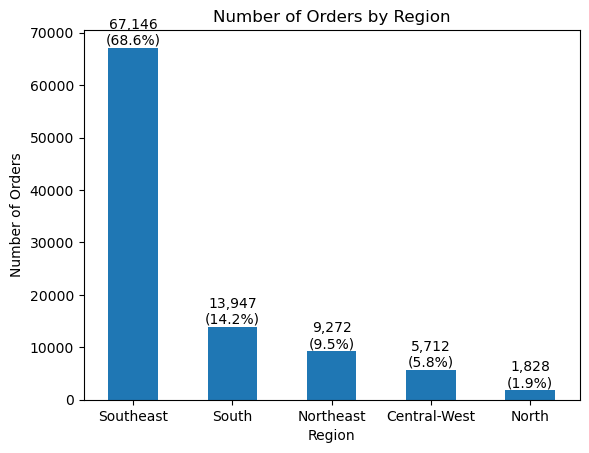

In [196]:
orders_by_region.plot(kind='bar')

plt.title('Number of Orders by Region')
plt.xlabel('Region')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)
total = orders_by_region.sum()

for i, value in enumerate(orders_by_region):
    percentage = (value / total) * 100
    plt.text(i, value, f'{value:,}\n({percentage:.1f}%)',
            ha='center', va='bottom')
plt.show()

In [197]:
customers_by_region = (sales.groupby('customer_region')['customer_unique_id'].nunique().sort_values(ascending=False))
sellers_by_region = (sales.groupby('seller_region')['seller_id'].nunique().sort_values(ascending=False))

In [198]:
region_comparison = pd.DataFrame({
    'Customers': customers_by_region,
    'Sellers': sellers_by_region})
region_comparison

,Customers,Sellers
Central-West,5533,79
North,1773,5
Northeast,9027,56
South,13508,660
Southeast,64885,2256


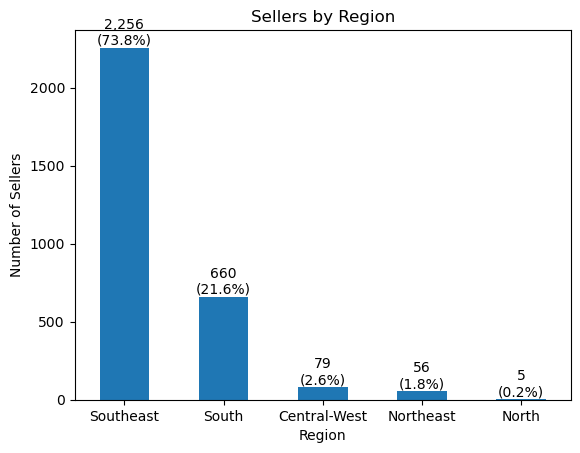

In [199]:
sellers_by_region.plot(kind='bar')

plt.title('Sellers by Region')
plt.xlabel('Region')
plt.ylabel('Number of Sellers')
plt.xticks(rotation=0)
total = sellers_by_region.sum()

for i, value in enumerate(sellers_by_region):
    percentage = (value / total) * 100
    plt.text(i, value, f'{value:,}\n({percentage:.1f}%)',
            ha='center', va='bottom')
plt.show()

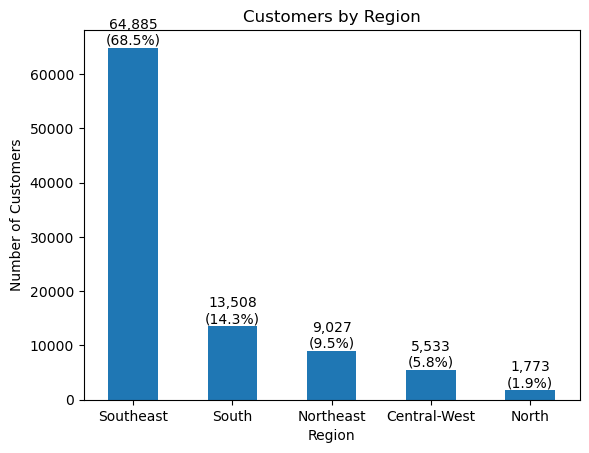

In [200]:
customers_by_region.plot(kind='bar')

plt.title('Customers by Region')
plt.xlabel('Region')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
total = customers_by_region.sum()

for i, value in enumerate(customers_by_region):
    percentage = (value / total) * 100
    plt.text(i, value, f'{value:,}\n({percentage:.1f}%)',
            ha='center', va='bottom')
plt.show()

In [201]:
#to see which stat have customer but dont have sellers 
sellers_by_state = (sellers.groupby('seller_state')['seller_id'].nunique())
sellers_by_state

seller_state
AC       1
AM       1
BA      19
CE      13
DF      30
ES      23
GO      40
MA       1
MG     244
MS       5
MT       4
PA       1
PB       6
PE       9
PI       1
PR     349
RJ     171
RN       5
RO       2
RS     129
SC     190
SE       2
SP    1849
Name: seller_id, dtype: int64

In [202]:
customers_by_state = (customers.groupby('customer_state')['customer_unique_id'].nunique())

customers_by_state

customer_state
AC       77
AL      401
AM      143
AP       67
BA     3277
CE     1313
DF     2075
ES     1964
GO     1952
MA      726
MG    11259
MS      694
MT      876
PA      949
PB      519
PE     1609
PI      482
PR     4882
RJ    12384
RN      474
RO      240
RR       45
RS     5277
SC     3534
SE      342
SP    40302
TO      273
Name: customer_unique_id, dtype: int64

In [203]:
state_gap = pd.DataFrame({'Customers': customers_by_state,'Sellers': sellers_by_state}).fillna(0)

state_gap

,Customers,Sellers
AC,77,1.0
AL,401,0.0
AM,143,1.0
AP,67,0.0
BA,3277,19.0
CE,1313,13.0
DF,2075,30.0
ES,1964,23.0
GO,1952,40.0
MA,726,1.0


In [204]:
customer_no_seller = state_gap[(state_gap['Customers'] > 0) &(state_gap['Sellers'] == 0)]

customer_no_seller

,Customers,Sellers
AL,401,0.0
AP,67,0.0
RR,45,0.0
TO,273,0.0


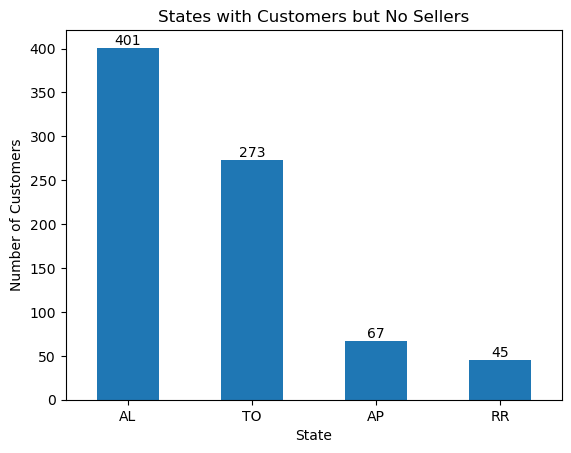

In [205]:
ax = customer_no_seller['Customers'].sort_values(ascending=False).plot(kind='bar')

plt.title('States with Customers but No Sellers')
plt.xlabel('State')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)

for i, value in enumerate(customer_no_seller['Customers'].sort_values(ascending=False)):
    ax.text(i, value, f'{value:,}', ha='center', va='bottom')

plt.show()

In [206]:
import numpy as np 

state_gap['Customers_per_Seller'] = (state_gap['Customers'] / state_gap['Sellers'].replace(0, np.nan))

In [207]:
low_coverage = state_gap.dropna(subset=['Customers_per_Seller']).sort_values('Customers_per_Seller',ascending=False).head(10)
low_coverage

,Customers,Sellers,Customers_per_Seller
PA,949,1.0,949.000000
MA,726,1.0,726.000000
PI,482,1.0,482.000000
MT,876,4.0,219.000000
PE,1609,9.0,178.777778
BA,3277,19.0,172.473684
SE,342,2.0,171.000000
AM,143,1.0,143.000000
MS,694,5.0,138.800000
RO,240,2.0,120.000000


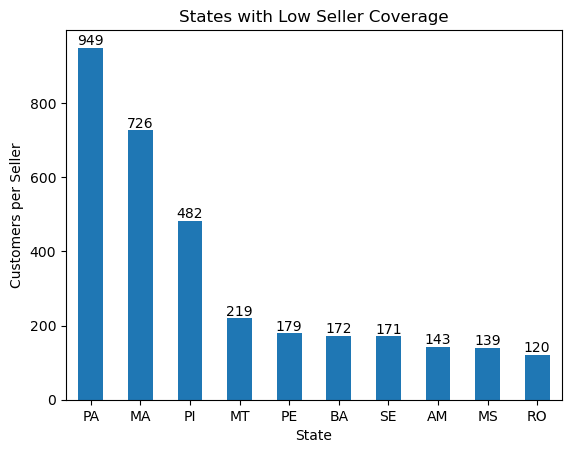

In [208]:
ax = low_coverage['Customers_per_Seller'].plot(kind='bar')

plt.title('States with Low Seller Coverage')
plt.xlabel('State')
plt.ylabel('Customers per Seller')
plt.xticks(rotation=0)

for i, value in enumerate(low_coverage['Customers_per_Seller']):
    ax.text(i, value, f'{value:.0f}', ha='center', va='bottom')

plt.show()

In [209]:
orders_by_state = (sales.groupby('customer_state')['order_id'].nunique().sort_values(ascending=False))


In [210]:
sales_by_state = (sales.groupby('customer_state')['price'].sum().sort_values(ascending=False))

In [211]:
state_performance = pd.DataFrame({'Customers': customers_by_state,'Orders': orders_by_state,'Sales': sales_by_state}).fillna(0)
state_performance['Orders_per_Customer'] = (state_performance['Orders'] /state_performance['Customers'])
state_performance['Sales_per_Customer'] = (state_performance['Sales'] / state_performance['Customers'])
state_performance

,Customers,Orders,Sales,Orders_per_Customer,Sales_per_Customer
customer_state,,,,,
AC,77,81,15982.95,1.051948,207.570779
AL,401,409,80232.32,1.019950,200.080599
AM,143,147,22356.84,1.027972,156.341538
AP,67,68,13474.30,1.014925,201.108955
BA,3277,3340,506214.78,1.019225,154.475063
CE,1313,1316,224574.68,1.002285,171.039360
DF,2075,2114,299842.68,1.018795,144.502496
ES,1964,2014,272614.34,1.025458,138.805672
GO,1952,1990,286886.07,1.019467,146.970323


In [212]:
state_performance['Sellers'] = state_gap['Sellers']

state_performance['Customers_per_Seller'] = (
    state_performance['Customers'] /
    state_performance['Sellers'].replace(0, np.nan)
)

state_performance.sort_values(
    'Customers_per_Seller',
    ascending=False
)[[
    'Customers',
    'Sellers',
    'Sales',
    'Customers_per_Seller'
]].head(10)

,Customers,Sellers,Sales,Customers_per_Seller
customer_state,,,,
PA,949,1.0,177733.52,949.000000
MA,726,1.0,118587.36,726.000000
PI,482,1.0,86450.09,482.000000
MT,876,4.0,155985.74,219.000000
PE,1609,9.0,260370.84,178.777778
BA,3277,19.0,506214.78,172.473684
SE,342,2.0,58635.40,171.000000
AM,143,1.0,22356.84,143.000000
MS,694,5.0,116754.65,138.800000


In [213]:
geolocation = pd.read_csv('olist_geolocation_dataset.csv')

In [214]:
state_location = (geolocation.groupby('geolocation_state')[['geolocation_lat', 'geolocation_lng']].mean().reset_index())

state_location.head()

,geolocation_state,geolocation_lat,geolocation_lng
0,AC,-9.702555,-68.451852
1,AL,-9.599729,-36.052017
2,AM,-3.349336,-60.537430
3,AP,0.086025,-51.234304
4,BA,-13.049361,-39.560649


# category

# wadeea analysis

In [215]:
category_name.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


In [216]:
category_name.isnull().sum()

product_category_name            0
product_category_name_english    0
dtype: int64

# to start part3 i will double check all data i need a gain  

In [217]:
clean_orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,year,month,quarter,weekday,hour
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,10,4,Monday,10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018,7,3,Tuesday,20
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018,8,3,Wednesday,8
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017,11,4,Saturday,19
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018,2,1,Tuesday,21


In [218]:
orders_item.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [219]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0,housewares


In [220]:
payment.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [221]:
category_name.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


## to check all columns name , and see in where sharing to merage 2 columns 

In [222]:
clean_orders.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'year', 'month', 'quarter', 'weekday', 'hour'],
      dtype='object')

In [223]:
orders_item.columns

Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='object')

In [224]:
products.columns

Index(['product_id', 'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'product_category_name_english'],
      dtype='object')

In [225]:
payment.columns

Index(['order_id', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value'],
      dtype='object')

In [226]:
category_name.columns

Index(['product_category_name', 'product_category_name_english'], dtype='object')

## to be sure all data dont have null and  each data what is the types 

In [227]:
clean_orders.info()

<class 'pandas.core.frame.DataFrame'>
Index: 99092 entries, 0 to 99440
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99092 non-null  object        
 1   customer_id                    99092 non-null  object        
 2   order_status                   99092 non-null  object        
 3   order_purchase_timestamp       99092 non-null  datetime64[ns]
 4   order_approved_at              98957 non-null  object        
 5   order_delivered_carrier_date   97376 non-null  datetime64[ns]
 6   order_delivered_customer_date  96204 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99092 non-null  datetime64[ns]
 8   year                           99092 non-null  int32         
 9   month                          99092 non-null  int32         
 10  quarter                        99092 non-null  int32         
 11  weekday             

In [228]:
orders_item.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [229]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   product_id                     32951 non-null  object 
 1   product_category_name          32341 non-null  object 
 2   product_name_lenght            32341 non-null  float64
 3   product_description_lenght     32341 non-null  float64
 4   product_photos_qty             32341 non-null  float64
 5   product_weight_g               32949 non-null  float64
 6   product_length_cm              32949 non-null  float64
 7   product_height_cm              32949 non-null  float64
 8   product_width_cm               32949 non-null  float64
 9   product_category_name_english  32341 non-null  object 
dtypes: float64(7), object(3)
memory usage: 2.5+ MB


In [230]:
payment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [231]:
category_name.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


# --What customers are buying and how they are paying

## 1-Which product categories have the highest and lowest total sales?

In [233]:
q1 = orders_item.merge(products, on="product_id")

In [234]:
sales = q1.groupby("product_category_name")["price"].sum()

In [235]:
sales.groupby("product_category_name")

In [236]:
pd.DataFrame({'Category': [sales.idxmax(), sales.idxmin()],'Sales': [sales.max(), sales.min()]})

,Category,Sales
0,beleza_saude,1258681.34
1,seguros_e_servicos,283.29


## 2-What is the average sale value per product category?

In [237]:
average = q1.groupby("product_category_name_english")["price"].mean()

In [238]:
average.sort_values(ascending=False).head(10)

product_category_name_english
computers                                1098.340542
small_appliances_home_oven_and_coffee     624.285658
home_appliances_2                         476.124958
agro_industry_and_commerce                342.124858
musical_instruments                       281.616000
small_appliances                          280.778468
portable kitchen food processors          264.568667
fixed_telephony                           225.693182
construction_tools_safety                 208.992371
watches_gifts                             201.135984
Name: price, dtype: float64

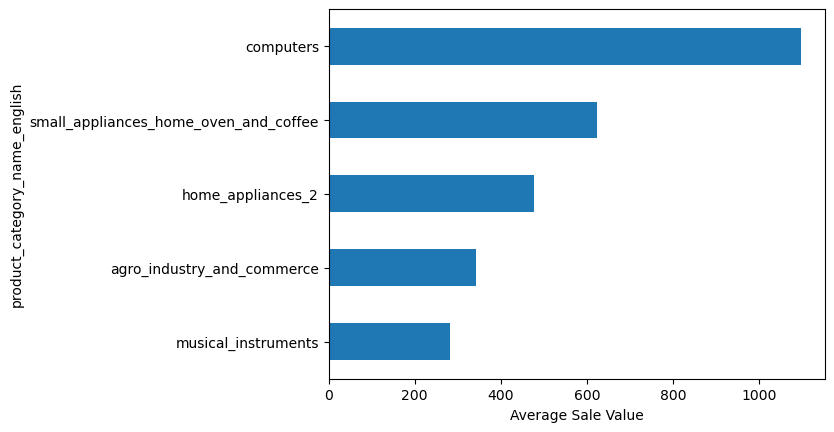

In [239]:
a=average.sort_values(ascending=False).head(5).plot(kind="barh")
plt.xlabel("Average Sale Value")
a.invert_yaxis()

## 3- Are certain product types driving peaks or dips in total sales?

Text(0, 0.5, 'Total Sales')

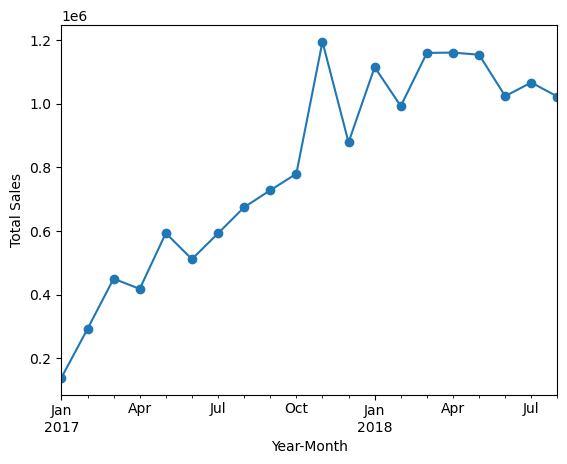

In [240]:
clean_orders['order_purchase_timestamp'] = pd.to_datetime(clean_orders['order_purchase_timestamp'])
merged = clean_orders.merge(payment[['order_id', 'payment_value']], on='order_id', how='inner')
merged['Year_Month'] = merged['order_purchase_timestamp'].dt.to_period('M')
sales = merged[merged['order_purchase_timestamp'].dt.year.isin([2017, 2018])].groupby('Year_Month')['payment_value'].sum()
sales.plot(kind='line', marker='o')
plt.xlabel('Year-Month')
plt.ylabel('Total Sales')


In [242]:
merged_products = merged.merge(q1[['order_id', 'product_category_name_english']], on='order_id', how='inner')
sales_2017_2018 = merged_products[merged_products['year'].isin([2017, 2018])]
product_types = sales_2017_2018.groupby('product_category_name_english')['payment_value'].sum().sort_values(ascending=False)
product_types.head()

product_category_name_english
bed_bath_table           1710261.96
health_beauty            1651310.96
computers_accessories    1582933.75
watches_gifts            1425748.64
furniture_decor          1419051.39
Name: payment_value, dtype: float64

Text(0, 0.5, 'Product Category')

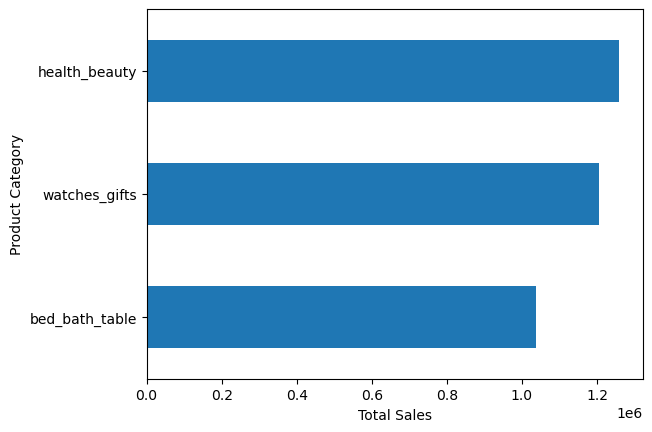

In [243]:
sales = q1.groupby("product_category_name_english")["price"].sum()
pek = sales.sort_values().head(3)
ax = sales.sort_values(ascending=False).head(3).plot(kind="barh")
ax.invert_yaxis()
plt.xlabel("Total Sales")
plt.ylabel("Product Category")

In [244]:
product_types.tail()

product_category_name_english
gaming PC                    2174.43
home_comfort_2               1710.54
cds_dvds_musicals            1199.43
fashion_childrens_clothes     785.67
security_and_services         324.51
Name: payment_value, dtype: float64

Text(0, 0.5, 'Product Category')

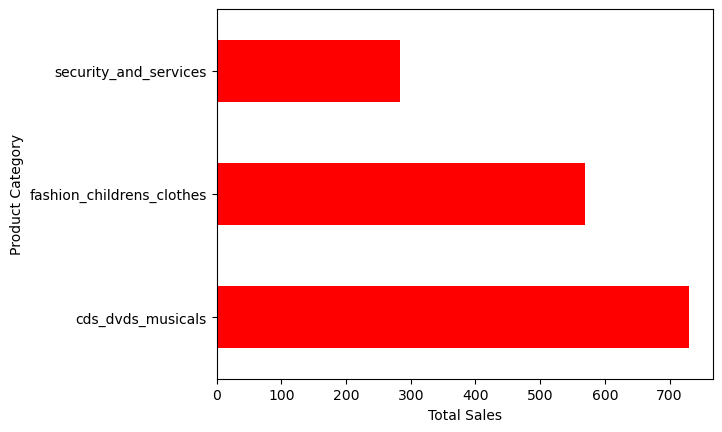

In [245]:
dip= sales.sort_values().head(3).plot(kind="barh", color="red")
dip.invert_yaxis()
plt.xlabel("Total Sales")
plt.ylabel("Product Category")

In [246]:
sales = q1.groupby("product_category_name_english")["price"].sum()
print(sales.idxmax())
print(sales.idxmin())

health_beauty
security_and_services


## 4-Do categories such as watches & gifts peak during festive seasons?

In [247]:
watches_gifts = q1[q1['product_category_name_english'] == 'watches_gifts']
watches_gifts

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
108,003d804eef0e1b856881cd18e0cc0d4c,1,41402af2a88247152583bb812ba235dd,4869f7a5dfa277a7dca6462dcf3b52b2,2017-11-27 12:15:18,277.0,35.74,relogios_presentes,53.0,486.0,2.0,533.0,20.0,8.0,11.0,watches_gifts
113,003f9bcc09427647c4b9d361a523545b,1,4bc3ab2ff016887e619e587a993af3bf,7e93a43ef30c4f03f38b393420bc753a,2018-02-12 13:15:37,229.0,9.80,relogios_presentes,44.0,516.0,1.0,500.0,20.0,11.0,15.0,watches_gifts
114,00404fa7a687c8c44ca69d42695aae73,1,53b36df67ebb7c41585e8d54d6772e08,7d13fca15225358621be4086e1eb0964,2018-05-15 04:31:26,99.9,0.00,relogios_presentes,33.0,523.0,3.0,584.0,16.0,11.0,13.0,watches_gifts
117,00418a49a685c6bb60633291c3fab17a,1,5e21d5cab5d33e770d8150a4ee6117db,6560211a19b47992c3666cc44a7e94c0,2017-10-09 20:50:45,49.0,7.78,relogios_presentes,60.0,312.0,4.0,200.0,16.0,2.0,11.0,watches_gifts
148,005a1dded353107dbabf8ffc83a20365,1,7e6c4a0bf900e259f50ba63331fd2785,6560211a19b47992c3666cc44a7e94c0,2018-02-15 18:10:50,75.0,14.28,relogios_presentes,59.0,755.0,2.0,250.0,16.0,2.0,11.0,watches_gifts
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112632,fff7c4452f050315db1b3f24d9df5fcd,1,dd469c03ad67e201bc2179ef077dcd48,7e93a43ef30c4f03f38b393420bc753a,2017-06-07 17:05:23,736.0,20.91,relogios_presentes,33.0,658.0,3.0,400.0,19.0,9.0,15.0,watches_gifts
112640,fffb9224b6fc7c43ebb0904318b10b5f,1,43423cdffde7fda63d0414ed38c11a73,b1fc4f64df5a0e8b6913ab38803c57a9,2017-11-03 02:55:58,55.0,34.19,relogios_presentes,41.0,1159.0,4.0,350.0,16.0,14.0,11.0,watches_gifts
112641,fffb9224b6fc7c43ebb0904318b10b5f,2,43423cdffde7fda63d0414ed38c11a73,b1fc4f64df5a0e8b6913ab38803c57a9,2017-11-03 02:55:58,55.0,34.19,relogios_presentes,41.0,1159.0,4.0,350.0,16.0,14.0,11.0,watches_gifts
112642,fffb9224b6fc7c43ebb0904318b10b5f,3,43423cdffde7fda63d0414ed38c11a73,b1fc4f64df5a0e8b6913ab38803c57a9,2017-11-03 02:55:58,55.0,34.19,relogios_presentes,41.0,1159.0,4.0,350.0,16.0,14.0,11.0,watches_gifts


In [248]:
q2 = q1.merge(clean_orders[['order_id', 'month']], on='order_id')

In [249]:
watches = q2[q2['product_category_name_english'] == 'watches_gifts']

C:\Users\97335\AppData\Local\Temp\ipykernel_5336\3133184927.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f'{x/1000:.0f}K' for x in ax.get_yticks()])


Text(0, 0.5, 'Total Sales')

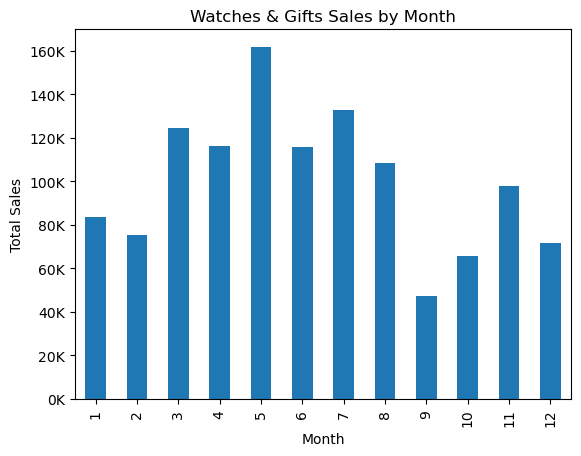

In [250]:
monthly_sales = watches.groupby('month')['price'].sum()
ax = monthly_sales.plot(kind='bar')
ax.set_yticklabels([f'{x/1000:.0f}K' for x in ax.get_yticks()])
plt.title('Watches & Gifts Sales by Month')
plt.xlabel('Month')
plt.ylabel('Total Sales')

## 5-Are discounts, vouchers, and installments helping or hurting sales performance?  

In [251]:
order_items_summary = orders_item.groupby('order_id').agg(
Total_Price=('price', 'sum'),
Total_Freight=('freight_value', 'sum')).reset_index()
payment_summary = payment.groupby('order_id').agg(
Total_Payment_Value=('payment_value', 'sum')).reset_index()
order_dis = order_items_summary.merge(payment_summary, on='order_id')
order_dis['Discounts'] = order_dis['Total_Payment_Value'] - (order_dis['Total_Price'] + order_dis['Total_Freight']).round(15)
order_dis[order_dis['Discounts'] >= 0]
order_dis['Discount_Status'] = order_dis['Discounts'].apply(lambda x: 'With Discount' if x < 0 else 'No Discount')



Text(0, 0.5, 'Total Sales')

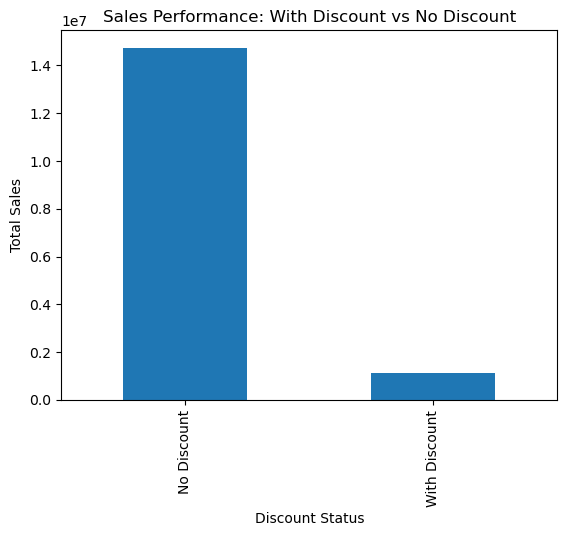

In [252]:
sales_perf = order_dis.groupby('Discount_Status')['Total_Payment_Value'].sum()
sales_perf.plot(kind='bar')
plt.title('Sales Performance: With Discount vs No Discount')
plt.xlabel('Discount Status')
plt.ylabel('Total Sales')


Text(0.5, 1.0, 'Voucher vs Non-Voucher Sales')

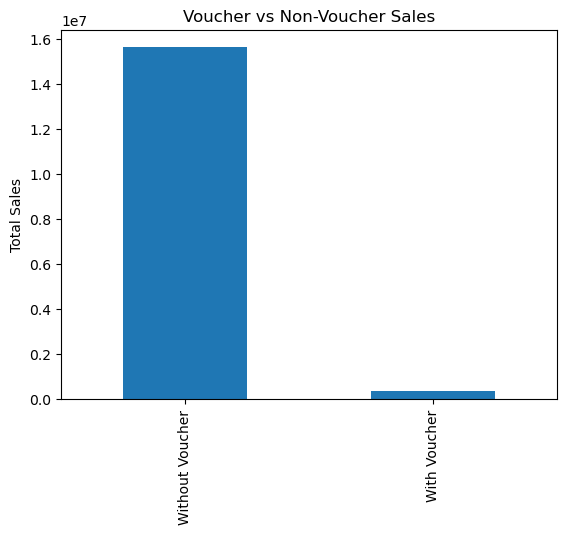

In [253]:
voucher_sales = payment.groupby(payment['payment_type'] == 'voucher').agg(
Total_Sales=('payment_value', 'sum'),
Total_Orders=('order_id', 'nunique'))
voucher_sales.index = ['Without Voucher', 'With Voucher']
voucher_sales['Total_Sales'].plot(kind='bar')
plt.ylabel('Total Sales')
plt.title('Voucher vs Non-Voucher Sales')

Text(0.5, 1.0, 'Sales by Installments')

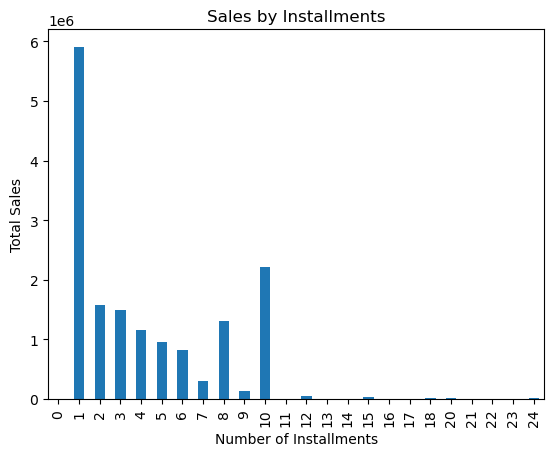

In [254]:
installments_sales = payment.groupby('payment_installments').agg(
Total_Sales=('payment_value', 'sum'),
Total_Orders=('order_id', 'nunique'))
installments_sales['Total_Sales'].plot(kind='bar')
plt.xlabel('Number of Installments')
plt.ylabel('Total Sales')
plt.title('Sales by Installments')